# El bosque que también es una biblioteca

En la Amazonía, **5.796 plantas** tienen un uso conocido para la gente: medicina, comida, construcción, veneno. Es **un tercio** de toda la flora con semilla del bioma.

Pero ese conocimiento vive en idiomas. Y de las **156 lenguas indígenas vivas** de la cuenca, el **55% están amenazadas**. Un equipo cruzó dos mapas: dónde se está apagando el idioma y dónde el clima golpeará más fuerte hacia **2060–2080**. Los dos se parecen demasiado.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *The forest of knowledge under global change* · Nature (2026)
**DOI:** [10.1038/s41586-026-10741-y](https://doi.org/10.1038/s41586-026-10741-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-08-amazonia-conocimiento/notebook.ipynb)

🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/wTO5pmZQO40)

## Qué hicieron

Reunieron **90.536 reportes** de uso de plantas sacados de **700 referencias** de toda la cuenca amazónica: qué especie, para qué sirve, qué pueblo la usa. De ahí salen las 5.796 especies útiles, repartidas en 195 familias.

Después modelaron hacia dónde podrían moverse esas plantas hacia **2060–2080** con **8.429 modelos** de distribución de especies (SDM), bajo 3 escenarios de emisiones y 5 modelos climáticos. Un detalle que manda sobre todo lo demás: **todo lo que sigue sobre "pérdida" es una proyección**, no algo ya medido.

La pregunta nueva es simple de enunciar y difícil de responder: ¿la pérdida proyectada de plantas útiles cae en los mismos lugares donde se están perdiendo las lenguas que guardan cómo usarlas?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HORIZONTE = '2060–2080'          # Ventana temporal de las proyecciones SDM
FUENTE = 'Fuente: Cámara-Leret et al. (2026), Nature | Datos: texto del paper (Open Access)'
COLOR_DATOS = '#2563EB'          # Azul CaM — región con lenguas NO amenazadas / dato base
COLOR_ALERTA = '#DC2626'         # Rojo — región con lenguas amenazadas / foco
COLOR_SECUND = '#059669'         # Emerald — datos secundarios
COLOR_REF = '#D97706'            # Amber — referencia

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 4 CSVs (valores extraídos del texto del paper, Open Access)
region = pd.read_csv('datos/perdida_por_region.csv')
familias = pd.read_csv('datos/familias_utilizadas.csv')
palmas = pd.read_csv('datos/palmas_citadas.csv')
categorias = pd.read_csv('datos/categorias_uso.csv')

# ── Pérdida proyectada por tipo de región lingüística ──
esp = region[region.variable == 'especies_perdidas'].set_index('tipo_region')
srv = region[region.variable == 'servicios_perdidos'].set_index('tipo_region')

esp_amen, esp_no = esp.loc['lenguas_amenazadas'], esp.loc['lenguas_no_amenazadas']
srv_amen, srv_no = srv.loc['lenguas_amenazadas'], srv.loc['lenguas_no_amenazadas']

ratio_esp = esp_amen.media_pct / esp_no.media_pct
ratio_srv = srv_amen.media_pct / srv_no.media_pct

# Tamaño de efecto estandarizado a partir de las medias y desviaciones
# reportadas (Cohen's d = diferencia de medias / SD combinada). Es una
# aproximación: el paper usa Wilcoxon (no paramétrico) sobre las regiones.
def cohen_d(m1, s1, m2, s2):
    sp = np.sqrt((s1**2 + s2**2) / 2)
    return (m1 - m2) / sp

d_esp = cohen_d(esp_amen.media_pct, esp_amen.sd_pct, esp_no.media_pct, esp_no.sd_pct)
d_srv = cohen_d(srv_amen.media_pct, srv_amen.sd_pct, srv_no.media_pct, srv_no.sd_pct)

print('PÉRDIDA PROYECTADA POR REGIÓN (hacia %s)' % HORIZONTE)
print(f'  Especies  → amenazada {esp_amen.media_pct:.0f}% ± {esp_amen.sd_pct:.0f}'
      f'  vs no amenazada {esp_no.media_pct:.0f}% ± {esp_no.sd_pct:.0f}')
print(f'            ratio {ratio_esp:.2f}x | Wilcoxon P = {esp_amen.p_value}'
      f' | d ≈ {d_esp:.2f} (medio)')
print(f'  Servicios → amenazada {srv_amen.media_pct:.0f}% ± {srv_amen.sd_pct:.0f}'
      f'  vs no amenazada {srv_no.media_pct:.0f}% ± {srv_no.sd_pct:.0f}')
print(f'            ratio {ratio_srv:.2f}x | Wilcoxon P = {srv_amen.p_value}'
      f' | d ≈ {d_srv:.2f} (medio)')

# ── Palmas: ¿la más citada es la más extendida? ──
rho, p_rho = stats.spearmanr(palmas.referencias, palmas.grupos_indigenas)
mas_citada = palmas.loc[palmas.referencias.idxmax()]
mas_pueblos = palmas.loc[palmas.grupos_indigenas.idxmax()]
print('\nPALMAS (n = %d)' % len(palmas))
print(f'  Más citada   : {mas_citada.especie} ({mas_citada.referencias} refs, '
      f'{mas_citada.grupos_indigenas} pueblos)')
print(f'  Más extendida: {mas_pueblos.especie} ({mas_pueblos.referencias} refs, '
      f'{mas_pueblos.grupos_indigenas} pueblos)')
print(f'  Spearman ρ = {rho:.2f} (n={len(palmas)}) → sin correlación clara')

# ── Familias y categorías ──
print('\nTOP FAMILIA: %s con %d especies (%.1fx la siguiente)'
      % (familias.iloc[0].familia, familias.iloc[0].especies_utilizadas,
         familias.iloc[0].especies_utilizadas / familias.iloc[1].especies_utilizadas))
_cat_es = {'Medicine': 'Medicina', 'HumanFood': 'Comida', 'Construction': 'Construcción'}
_lider = categorias.iloc[0].categoria_uso
print('CATEGORÍA LÍDER (subconjunto modelado): %s con %d especies'
      % (_cat_es.get(_lider, _lider), categorias.iloc[0].n_especies))

PÉRDIDA PROYECTADA POR REGIÓN (hacia 2060–2080)
  Especies  → amenazada 39% ± 27  vs no amenazada 25% ± 20
            ratio 1.56x | Wilcoxon P = 0.0043 | d ≈ 0.59 (medio)
  Servicios → amenazada 27% ± 20  vs no amenazada 17% ± 15
            ratio 1.59x | Wilcoxon P = 0.0018 | d ≈ 0.57 (medio)

PALMAS (n = 5)
  Más citada   : Bactris gasipaes (178 refs, 58 pueblos)
  Más extendida: Mauritia flexuosa (165 refs, 66 pueblos)
  Spearman ρ = 0.10 (n=5) → sin correlación clara

TOP FAMILIA: Fabaceae con 662 especies (2.0x la siguiente)
CATEGORÍA LÍDER (subconjunto modelado): Medicina con 1238 especies


## Aquí está.

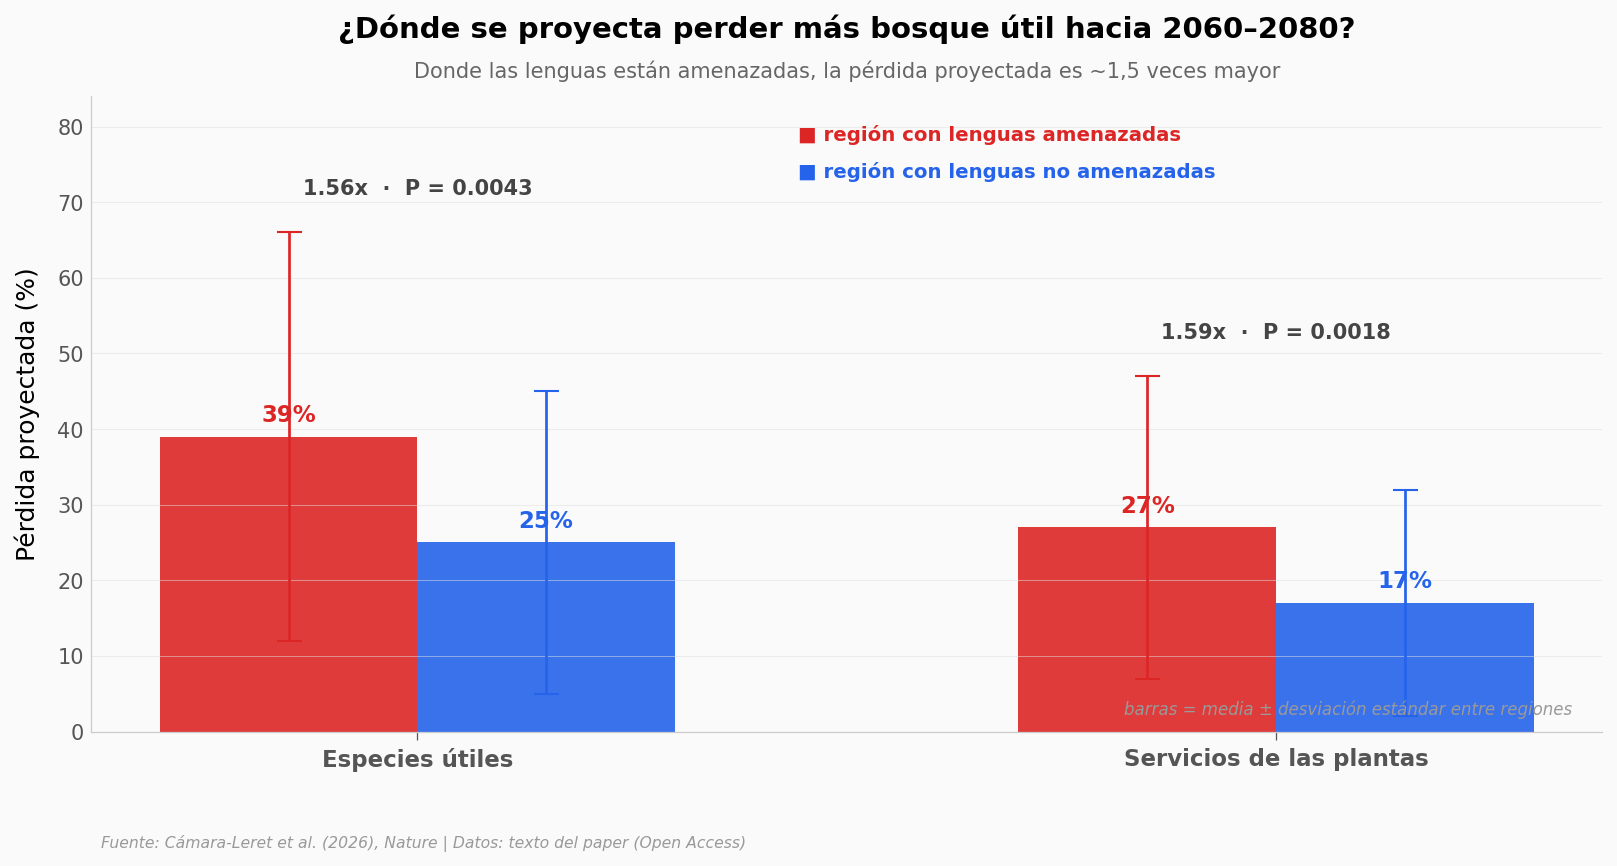

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Dos bloques (especies, servicios); dentro de cada uno, amenazada vs no
grupos = ['Especies útiles', 'Servicios de las plantas']
amen = [esp_amen.media_pct, srv_amen.media_pct]
amen_sd = [esp_amen.sd_pct, srv_amen.sd_pct]
noam = [esp_no.media_pct, srv_no.media_pct]
noam_sd = [esp_no.sd_pct, srv_no.sd_pct]

x = np.array([0, 1.4])
w = 0.42
ax.bar(x - w/2, amen, w, yerr=amen_sd, color=COLOR_ALERTA, alpha=0.9,
       capsize=6, error_kw=dict(lw=1.3, ecolor='#DC2626'))
ax.bar(x + w/2, noam, w, yerr=noam_sd, color=COLOR_DATOS, alpha=0.9,
       capsize=6, error_kw=dict(lw=1.3, ecolor='#2563EB'))

# Etiqueta de valor sobre cada barra
for xi, (va, vn) in zip(x, zip(amen, noam)):
    ax.text(xi - w/2, va + 2, f'{va:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_ALERTA)
    ax.text(xi + w/2, vn + 2, f'{vn:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_DATOS)

# Anotar el múltiplo y la P de Wilcoxon justo sobre el tope de cada bloque
ax.text(x[0], 71, f'{ratio_esp:.2f}x  ·  P = {esp_amen.p_value}', ha='center',
        fontsize=10, color='#444444', fontweight='bold')
ax.text(x[1], 52, f'{ratio_srv:.2f}x  ·  P = {srv_amen.p_value}', ha='center',
        fontsize=10, color='#444444', fontweight='bold')

# Clave de color inline (reemplaza legend box) — en el hueco central superior
ax.text(0.62, 79, '■ región con lenguas amenazadas', fontsize=9.5,
        color=COLOR_ALERTA, fontweight='bold', va='center')
ax.text(0.62, 74, '■ región con lenguas no amenazadas', fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', va='center')

ax.set_xticks(x)
ax.set_xticklabels(grupos, fontsize=11, fontweight='bold')
ax.set_ylabel('Pérdida proyectada (%)')
ax.set_ylim(0, 84)
ax.set_title('¿Dónde se proyecta perder más bosque útil hacia 2060–2080?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Donde las lenguas están amenazadas, la pérdida proyectada es ~1,5 veces mayor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, 'barras = media ± desviación estándar entre regiones',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right',
        va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_perdida_region.png', dpi=200, bbox_inches='tight')
plt.show()

Las regiones donde las lenguas indígenas están amenazadas muestran una pérdida proyectada mayor en las dos cosas: **39% de las especies útiles frente a 25%** donde las lenguas no lo están (1,56 veces más), y **27% de los servicios frente a 17%** (1,59 veces). Las dos brechas pasan el test de Wilcoxon (P = 0,0043 y P = 0,0018).

Vale la pena leer las barras de error: las desviaciones son grandes (±20 a ±27 puntos), así que hay regiones amenazadas que pierden poco y regiones tranquilas que pierden bastante. Lo que el paper apunta no es que cada píxel siga la regla, sino que **en promedio** los dos frentes —el del idioma y el del clima— se solapan.

Y ojo con el verbo: esto no dice que perder la lengua *cause* perder las plantas. Son dos mapas que coinciden en el espacio. La coincidencia ya es suficientemente incómoda.

## ¿Qué conocimiento está en juego?

Si el bosque útil se encoge, no se pierde "plantas" en abstracto. Se pierde para qué servían. Veamos en qué se reparten las especies que el equipo alcanzó a modelar.

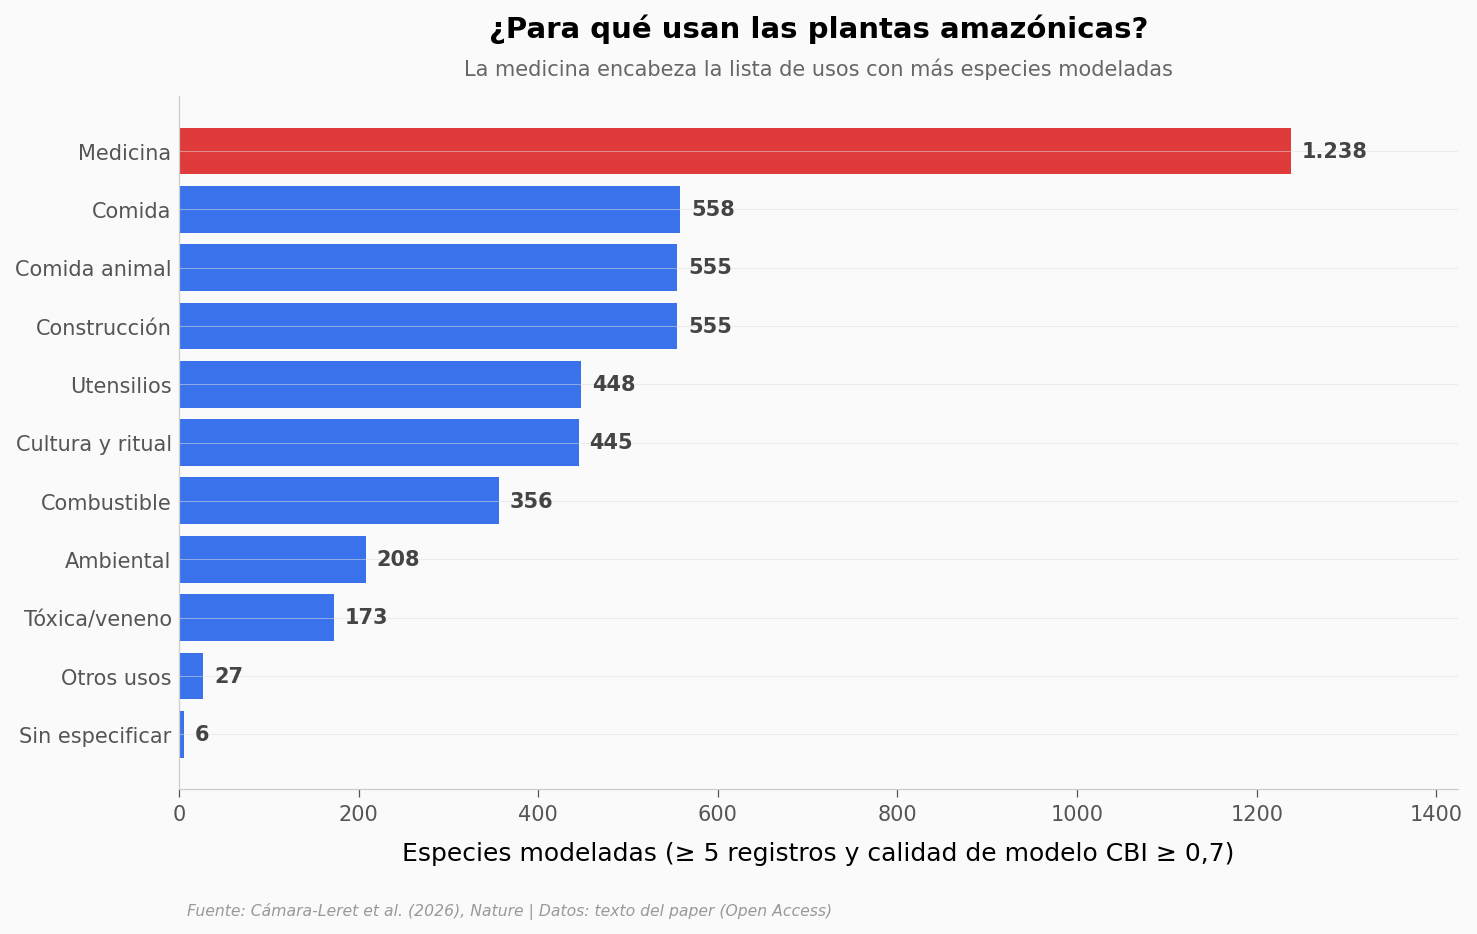

In [3]:
cat = categorias.sort_values('n_especies', ascending=True).reset_index(drop=True)
# Traducción de las etiquetas del paper (columnas en inglés en el CSV)
etiquetas = {
    'Medicine': 'Medicina', 'HumanFood': 'Comida', 'Construction': 'Construcción',
    'AnimalFood': 'Comida animal', 'UtensilsAndTools': 'Utensilios',
    'Culture': 'Cultura y ritual', 'Fuel': 'Combustible',
    'Environmental': 'Ambiental', 'Toxic': 'Tóxica/veneno',
    'OtherUses': 'Otros usos', 'NotSpecified': 'Sin especificar',
}
cat['label'] = cat.categoria_uso.map(etiquetas)
colores = [COLOR_ALERTA if c == 'Medicine' else COLOR_DATOS for c in cat.categoria_uso]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(cat.label, cat.n_especies, color=colores, alpha=0.9)
for n, y in zip(cat.n_especies, range(len(cat))):
    ax.text(n + 12, y, f'{n:,}'.replace(',', '.'), va='center', fontsize=10,
            fontweight='bold', color='#444444')

ax.set_xlabel('Especies modeladas (≥ 5 registros y calidad de modelo CBI ≥ 0,7)')
ax.set_xlim(0, cat.n_especies.max() * 1.15)
ax.set_title('¿Para qué usan las plantas amazónicas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La medicina encabeza la lista de usos con más especies modeladas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/categorias_uso.png', dpi=200, bbox_inches='tight')
plt.show()

La medicina domina: **1.238 especies modeladas** entran en esa casilla, más que comida y construcción juntas. (Cuidado con el número: son las especies que pasaron el filtro para modelar, no las 3.862 medicinales totales del dataset. Una misma planta puede caer en varias casillas.) A nivel de reportes crudos la diferencia es aún más marcada: cerca de tres veces más menciones de uso medicinal que alimentario.

Pero saber *cuántas* especies hay por uso no cuenta cómo circula ese conocimiento entre pueblos. Para eso hay que mirar planta por planta. Y las palmas dan la mejor pista.

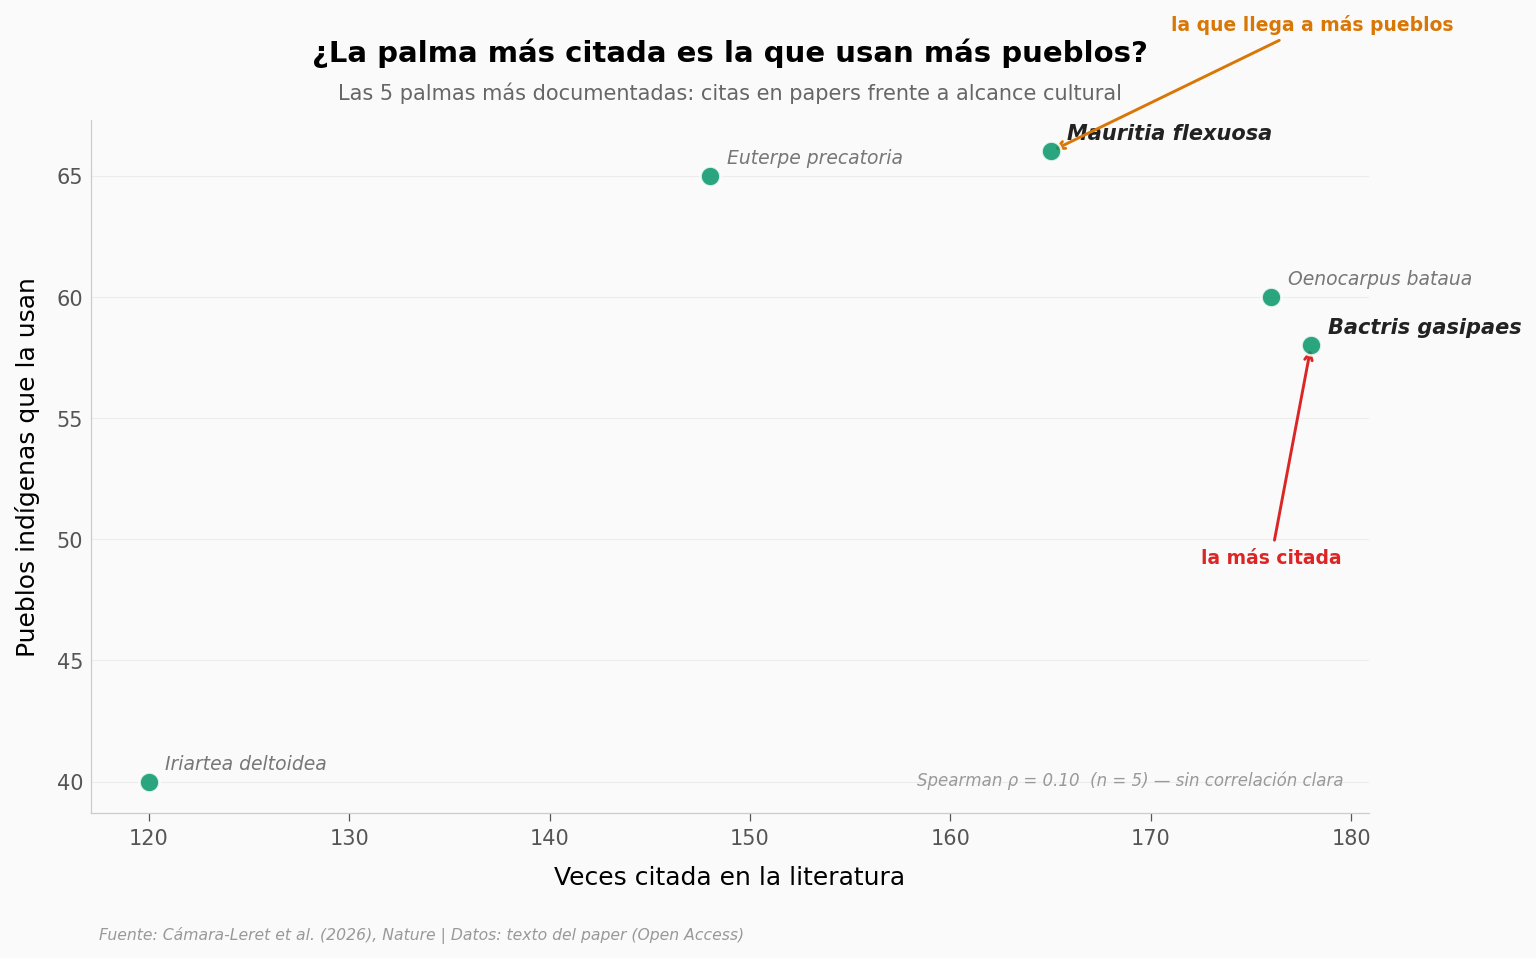

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(palmas.referencias, palmas.grupos_indigenas, s=90, color=COLOR_SECUND,
           alpha=0.85, edgecolors='white', linewidths=1.2, zorder=5)

# Etiqueta cada palma; resalta la más citada y la más extendida
for _, r in palmas.iterrows():
    destaca = r.especie in (mas_citada.especie, mas_pueblos.especie)
    ax.annotate(r.especie,
                (r.referencias, r.grupos_indigenas),
                xytext=(8, 6), textcoords='offset points',
                fontsize=10 if destaca else 9,
                fontstyle='italic',
                fontweight='bold' if destaca else 'normal',
                color='#222222' if destaca else '#777777')

# Flechas que nombran la divergencia
ax.annotate('la más citada', (mas_citada.referencias, mas_citada.grupos_indigenas),
            xytext=(mas_citada.referencias - 2, mas_citada.grupos_indigenas - 9),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))
ax.annotate('la que llega a más pueblos',
            (mas_pueblos.referencias, mas_pueblos.grupos_indigenas),
            xytext=(mas_pueblos.referencias + 6, mas_pueblos.grupos_indigenas + 5),
            fontsize=9, color=COLOR_REF, fontweight='bold', ha='left',
            arrowprops=dict(arrowstyle='->', color=COLOR_REF, lw=1.4))

ax.set_xlabel('Veces citada en la literatura')
ax.set_ylabel('Pueblos indígenas que la usan')
ax.set_title('¿La palma más citada es la que usan más pueblos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las 5 palmas más documentadas: citas en papers frente a alcance cultural',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.04, f'Spearman ρ = {rho:.2f}  (n = {len(palmas)}) — sin correlación clara',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/palmas_divergencia.png', dpi=200, bbox_inches='tight')
plt.show()

La respuesta es no. **Bactris gasipaes** (el chontaduro) es la más citada con 178 referencias, pero **Mauritia flexuosa** (el moriche o aguaje) llega a más pueblos: 66 grupos frente a 58. Con solo cinco palmas la correlación no existe (ρ = 0,10). Citar mucho una planta y que muchos pueblos la usen son dos cosas distintas — y esa distinción es justo lo que se pierde cuando se apaga una lengua sin que nadie la haya escrito.

## Una última pregunta de escala

¿Cuánta planta útil sostiene todo esto? Detrás de las 5.796 especies hay unas pocas familias que hacen el trabajo pesado.

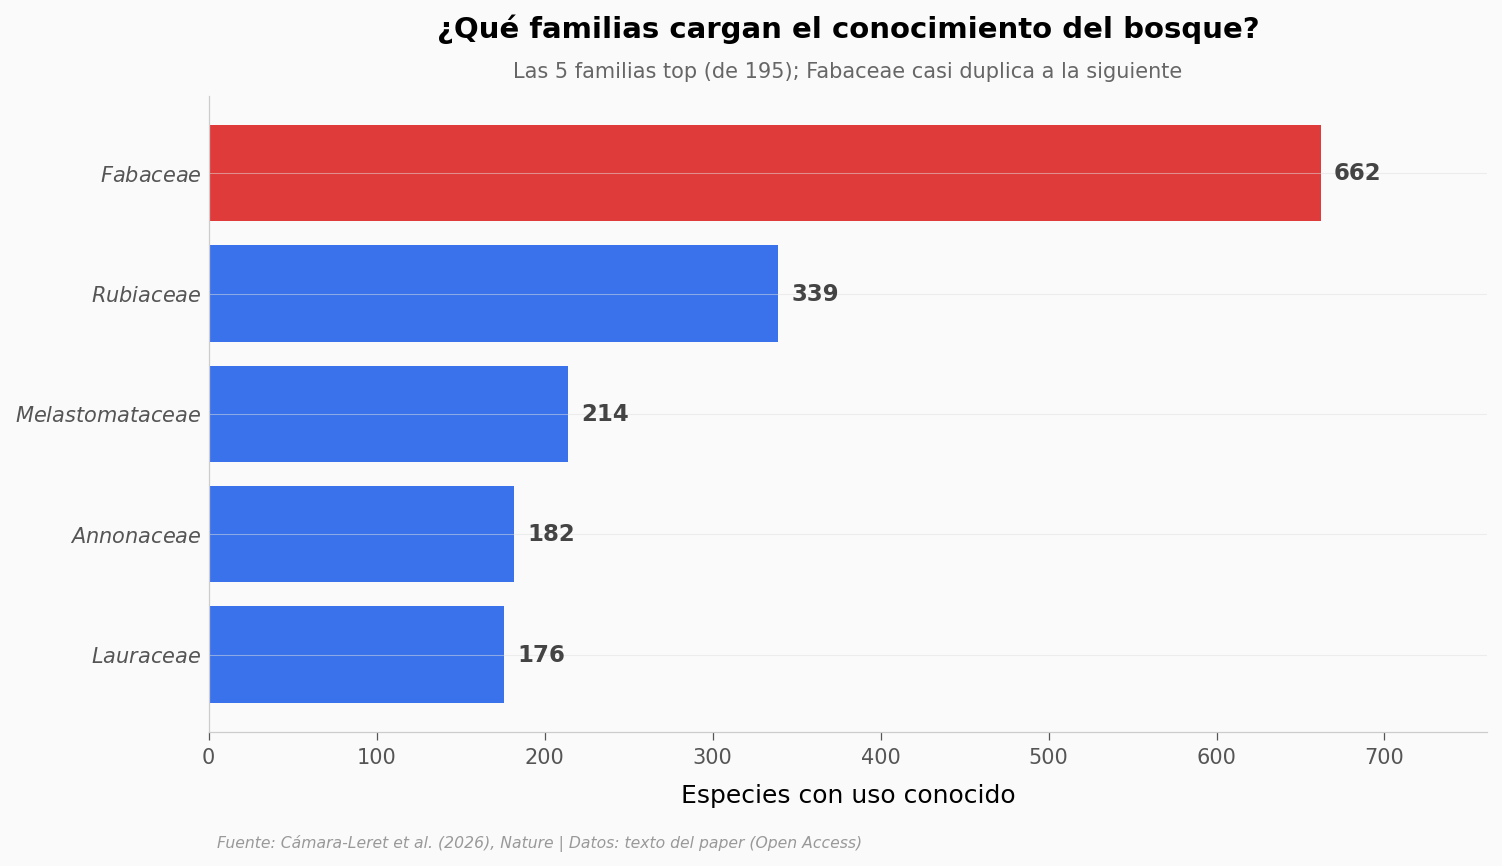

In [5]:
fam = familias.sort_values('especies_utilizadas', ascending=True).reset_index(drop=True)
colores_fam = [COLOR_ALERTA if f == 'Fabaceae' else COLOR_DATOS for f in fam.familia]

fig, ax = plt.subplots(figsize=(11, 5.5))
ypos = range(len(fam))
ax.barh(ypos, fam.especies_utilizadas, color=colores_fam, alpha=0.9)
for n, y in zip(fam.especies_utilizadas, ypos):
    ax.text(n + 8, y, f'{n:,}'.replace(',', '.'), va='center', fontsize=11,
            fontweight='bold', color='#444444')

ax.set_xlabel('Especies con uso conocido')
ax.set_xlim(0, fam.especies_utilizadas.max() * 1.15)
ax.set_yticks(ypos)
ax.set_yticklabels([f'$\\it{{{f}}}$' for f in fam.familia])
ax.set_title('¿Qué familias cargan el conocimiento del bosque?',
             fontsize=14, fontweight='bold', pad=28)
ratio_fam = fam.iloc[-1].especies_utilizadas / fam.iloc[-2].especies_utilizadas
ax.text(0.5, 1.03,
        f'Las 5 familias top (de 195); Fabaceae casi duplica a la siguiente',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/familias_top.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las regiones con lenguas amenazadas muestran mayor pérdida **proyectada** de especies (39% vs 25%) | ✅ | +14 pp, 1,56x, Wilcoxon P = 0,0043, tamaño de efecto d ≈ 0,59 (medio). Comparación **observacional** entre regiones de valores **proyectados** a 2060–2080. |
| Lo mismo para los servicios de las plantas (27% vs 17%) | ✅ | +10 pp, 1,59x, P = 0,0018, d ≈ 0,57 (medio). |
| La medicina es el uso con más especies modeladas (1.238) | ✅ | Es el subconjunto modelable (occ ≥ 5, CBI ≥ 0,7), no el total de 3.862 medicinales. Especies multiuso cuentan en varias casillas. |
| La palma más citada no es la que llega a más pueblos | ✅ | *Bactris gasipaes* lidera en citas (178); *Mauritia flexuosa* en pueblos (66). ρ = 0,10 con n = 5 → sin correlación. |
| Fabaceae es la familia con más especies útiles (662) | ✅ | Casi el doble de Rubiaceae (339); 11,4% de las 5.796. |

> **Limitaciones.** (1) Toda "pérdida" es una **proyección** de modelos de distribución (SDM) a 2060–2080, no una medición. (2) La comparación entre regiones es **observacional**: coincidencia espacial, no causalidad — perder la lengua no *causa* perder la planta. (3) Los valores se extrajeron del texto del paper (Open Access), no del ZIP de rásters (10,5 GB); las cifras coinciden con los comentarios del código en Zenodo. (4) El tamaño de efecto d se estima a partir de las medias y desviaciones reportadas; el paper usa Wilcoxon, no paramétrico. (5) Palmas con n = 5: cualquier correlación es anecdótica.

## Ahora tú

Los datos están en `datos/`. Tres preguntas para explorar:

1. **¿Y si comparas la brecha entre especies y servicios?** La región amenazada pierde 39% de especies pero 27% de servicios. ¿Por qué el golpe a las especies es mayor que a los servicios? *Pista: mira `region` y calcula la diferencia dentro de cada tipo de región.*

2. **¿Cuánto pesa la medicina frente al resto?** Suma todas las categorías menos medicina y compárala. *Pista: `categorias[categorias.categoria_uso != 'Medicine'].n_especies.sum()`.*

3. **¿Se sostiene la divergencia si sumas citas + pueblos en un solo índice?** Crea una columna combinada y reordena las palmas. ¿Cambia quién queda arriba? *Pista: `palmas['indice'] = palmas.referencias + palmas.grupos_indigenas`.*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿el golpe a especies es más duro que a servicios en cada región?
brecha = pd.DataFrame({
    'tipo_region': ['lenguas_amenazadas', 'lenguas_no_amenazadas'],
    'especies_%': [esp_amen.media_pct, esp_no.media_pct],
    'servicios_%': [srv_amen.media_pct, srv_no.media_pct],
})
brecha['especies_menos_servicios_pp'] = brecha['especies_%'] - brecha['servicios_%']
print(brecha.to_string(index=False))
print()
# En las dos regiones la pérdida proyectada de especies supera a la de servicios
# por ~10-12 pp: se proyecta perder plantas más rápido que los usos que sobreviven
# en las especies que quedan (un mismo uso suele tener varias especies suplentes).

          tipo_region  especies_%  servicios_%  especies_menos_servicios_pp
   lenguas_amenazadas          39           27                           12
lenguas_no_amenazadas          25           17                            8



## Fuentes

**Paper**: [The forest of knowledge under global change](https://doi.org/10.1038/s41586-026-10741-y)  
*Nature, 2026-07-08*

**Dataset canonico**: [The Forest of Knowledge — data & code (Cámara-Leret et al. 2026)](https://doi.org/10.5281/zenodo.19202485)

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com) · datos y código reproducibles en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Licencia CC BY 4.0.*